<center>
    <h1 style="color:#00BFFF;">🛰️😄 Jugando con APIs en Python - 1</h1>
    <h4>Un paseo divertido por el mundo de las APIs REST</h4>
</center>

---

En este notebook vas a aprender a usar **APIs web** desde Python de forma práctica y entretenida:

Todo ello paso a paso, con código guiado, explicaciones y pequeñas preguntas para que vayas pensando como una persona que programa en datos 👩‍💻👨‍💻.

<center>
<img src="https://openclipart.org/image/400px/215664"
    style="width:35%;">
    <h1 style="color: #00BFFF;">APIs</h1>
</center>

## 0️⃣ ¿Qué es una API (y por qué te interesa)?

Una **API** (Application Programming Interface) es como una **ventanilla** a la que puedes ir a pedir información.

En el caso de las **APIs web**:
- Haces peticiones a una URL (llamada **endpoint**).
- Sueles usar el método **GET** cuando quieres *leer* datos.
- El servidor te responde normalmente en formato **JSON**, que es muy cómodo de manejar en Python.

Ventajas de usar APIs:
- Puedes obtener **datos en tiempo real** (posiciones, tiempo, noticias, etc.).
- Evitas descargar archivos a mano cada vez.
- Puedes automatizar tareas: que tu script llame a la API, guarde datos y los analice.

💡 **Mini reto:**
- Piensa en una app o web que uses a diario. ¿Qué tipo de APIs podría estar usando por detrás?

![](https://github.com/data-bootcamp-v4/lessons/blob/main/img/request-response.png?raw=true)

### Resumen teórico sobre APIs REST

Las **APIs REST** permiten que diferentes sistemas se comuniquen entre sí usando peticiones web. Son una forma estandarizada de **acceder, enviar, modificar o borrar datos** de un servidor.

#### 🔹 ¿Cómo funciona una API REST?
- El **cliente** (nuestro código en Python) envía una **petición HTTP**.
- El **servidor** responde con datos, normalmente en formato **JSON**.
- Cada operación se realiza a través de un **endpoint**, que es una URL concreta.

#### 🔹 JSON: el lenguaje de las respuestas
- JSON se parece a los diccionarios de Python, con estructura basada en `"clave": valor`.
- Aunque visualmente parezca un diccionario, la respuesta completa llega como **texto (string)**.
- Posteriormente lo convertimos en estructuras Python con `.json()`.

#### 🔹 Parámetros en las APIs
- Muchas APIs requieren **parámetros**, igual que una función en Python.
- Se envían en la URL (query parameters) o en el body en caso de otros métodos.
- Algunos endpoints exigen **API keys** para autenticación.

#### 🔹 Documentación
Cada API funciona de manera distinta. La documentación indica:
- Qué endpoints existen.
- Qué parámetros permiten.
- Qué devuelven.
- Ejemplos de uso.

Leer la documentación es esencial cuando empiezas a trabajar con APIs.

#### 🔹 Explora más APIs
Existen miles de APIs públicas gratuitas.  
Puedes explorar muchas de ellas aquí:

👉 https://github.com/public-apis/public-apis

![](https://github.com/data-bootcamp-v4/lessons/blob/main/img/api.png?raw=true)

## 1️⃣ Librerías que vas a usar

- `requests`: para hablar con las APIs (HTTP).
- `pandas`: para crear DataFrames y analizarlos.
- `time`: para pausar un poco entre llamadas si hace falta.
- `matplotlib`: para hacer gráficos sencillos.

In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

##### **Las APIs RESTful** proporcionan una **forma estandarizada** de recuperar, actualizar o eliminar datos de otros sistemas.

- Normalmente, **nosotros (el cliente) enviamos una solicitud y ellos (el servidor) devuelven una respuesta, a menudo en formato JSON (JavaScript Object Notation)**.  
  Aunque JSON se parece a los diccionarios que usamos en Python, es importante recordar que cuando aparece como texto puro (por ejemplo, en la respuesta de una API), **toda la estructura JSON es una *cadena de texto***.  
  Sin embargo, dentro de esa estructura, JSON puede representar distintos tipos de datos como números, booleanos y listas, no solo cadenas.

- Las APIs siempre deben proporcionar documentación para sus distintos servicios: los **endpoints**.  
  Cada endpoint corresponde a una URL diferente.

- A veces tenemos que pasar **parámetros** a un endpoint, de forma similar a cuando pasamos parámetros a una función en Python.

En este punto del Bootcamp, **leer documentación se vuelve esencial**, ya que cada API “funciona” de manera diferente y, para poder usarla, necesitamos saber qué exige.

[Aquí](https://github.com/public-apis/public-apis) tienes un repositorio donde puedes encontrar varias APIs gratuitas por si te apetece explorar un poco.


![](https://github.com/data-bootcamp-v4/lessons/blob/main/img/http.png?raw=true)

Puedes hacer peticiones a APIs RESTful usando librerías como `requests` (la misma que usamos para web scraping).


<h1 style="color: #00BFFF;">🛰️ 2️⃣ API de la ISS: ver dónde está la Estación Espacial Internacional</h1>


<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/17/STS-134_EVA4_view_to_the_Space_Shuttle_Endeavour.jpg/1920px-STS-134_EVA4_view_to_the_Space_Shuttle_Endeavour.jpg"
    style="width:40%;">
</center>

Cogeremos información de la ISS (International Space Station)! Primero hay que mirar a su documentación [ISS API documentation](https://wheretheiss.at/w/developer)

Vamos a usar una API pública muy sencilla que devuelve la **posición actual** de la ISS.

Endpoint (URL):
```text
http://api.open-notify.org/iss-now.json
```

Primero haremos una petición básica y veremos qué nos responde.

<h2 style="color: #008080;">Endpoints</h2>

#### Accediendo al **endpoint**

APIs siempre tienen que proveer información de sus servicios: **endpoints**.  Cada endpoint es una URL diferente.  

In [3]:
# Esta url nos da información sobre los satélites
url = "https://api.wheretheiss.at/v1/satellites"

**Ejemplos**
- Detalles de todos los satélites: `https://api.wheretheiss.at/v1/satellites`
- ISS posicion de uno en concreto: `https://api.wheretheiss.at/v1/satellites/25544`
- Información sobre unas determinadas coordenadas: `https://api.wheretheiss.at/v1/coordinates/37.795517,-122.393693`


Esta API permite acceder a distintos datos relacionados con la Estación Espacial Internacional (ISS), incluyendo su posición actual, pasada o futura, información de zona horaria para coordenadas específicas y más.

**Características principales**
- **Autenticación**: Actualmente no requiere autenticación, pero futuros endpoints podrían necesitarla.
- **Límite de peticiones**: Aproximadamente 1 petición por segundo.
- **Respuestas**: Por defecto en formato JSON, con parámetros opcionales para modificar el formato de salida.
- **Endpoints**: Varios endpoints ofrecen distintos tipos de información:
    - **satellites**: Información sobre satélites, incluida la ISS.



<h2 style="color: #008080;">GET</h2>

Making a `GET request` to the API is simply a call to a `URL` that returns information.

Aquí tienes un ejemplo de "request" en Python:

```python
url = "https://api.example.com/products"
response = requests.get(url)

if response.status_code == 200:
    products = response.json()
    # Con esto ya puedes analizar tus productos
```

In [5]:
response = requests.get(url)
response

<Response [200]>

In [7]:
data = response.json()

In [9]:
# Mira la data
data

[{'name': 'iss', 'id': 25544}]

In [11]:
# Qué elemento es?
type(data)

list

In [13]:
# Cuántos satélites hay?
len(data)

1

In [21]:
# Cómo obtienes el id de este satélite?
str(data[0]['id'])


'25544'

💡 **Preguntas rápidas:**
- Si el código de estado es **200**, ¿qué significa?
- ¿Qué claves (`keys`) ves en el diccionario JSON que devuelve la API?

In [25]:
data[0].keys()

dict_keys(['name', 'id'])

In [27]:
# ¿Cómo sacarias el id de este satelite? Conviertelo en string
id_ = str(data[0]['id'])
id_

'25544'

In [29]:
# Crea la url del id
url_id = url + '/' + id_
url_id

'https://api.wheretheiss.at/v1/satellites/25544'

In [31]:
# AHORA CAMBIAMOS DE ENDPOINT Y REPETIMOS EL PROCESO
response2 = requests.get(url_id)
data_id = response2.json()
data_id

{'name': 'iss',
 'id': 25544,
 'latitude': -9.0328215500232,
 'longitude': 1.0774656612781,
 'altitude': 419.42312551518,
 'velocity': 27578.342912314,
 'visibility': 'daylight',
 'footprint': 4504.5274169627,
 'timestamp': 1765981925,
 'daynum': 2461027.1056134,
 'solar_lat': -23.374931324349,
 'solar_lon': 321.0434214863,
 'units': 'kilometers'}

In [33]:
# Qué elemento me ha devuelto ahora?
type(data_id)

dict

- Los parámetros de una API son valores específicos que se incluyen en una petición a un endpoint para **filtrar, ordenar o detallar** los datos que deseas obtener. Permiten personalizar la solicitud para conseguir exactamente la información que necesitas.

- Existen varios tipos de parámetros que pueden utilizarse en las peticiones a una API, como **Path Parameters**, **Query Parameters**, **Header Parameters** y **Request Body Parameters**. Veámoslos con un ejemplo usando otro endpoint.

- **Endpoints**: Varios endpoints proporcionan diferentes tipos de información:
    - **satellites**: Información sobre satélites, incluida la ISS.
    - **satellites/[id]**: Posición, velocidad e información relacionada con un satélite.

##### **Path Parameters**

Estos parámetros van incrustados en la propia ruta de la URL y se utilizan para identificar un recurso específico.  
Por ejemplo, en la URL `https://api.wheretheiss.at/v1/satellites/25544`, el número `25544` es un *path parameter* que identifica un satélite concreto.


<h2 style="color: #008080;">Path Parameters</h2>

In [35]:
key = str(data[0]["id"])

In [37]:
iss = "https://api.wheretheiss.at/v1/satellites/"+key

In [39]:
response = requests.get(iss)
data_particular = response.json()

In [40]:
data_particular

{'name': 'iss',
 'id': 25544,
 'latitude': -15.403429703153,
 'longitude': 5.8772771132044,
 'altitude': 420.77540483781,
 'velocity': 27575.019776841,
 'visibility': 'daylight',
 'footprint': 4511.4062703273,
 'timestamp': 1765982052,
 'daynum': 2461027.1070833,
 'solar_lat': -23.374977613571,
 'solar_lon': 320.51443495312,
 'units': 'kilometers'}

<h2 style="color: #008080;">Recopilemos datos</h2>

In [43]:
# Convertimos la posición obtenida en un datafram
df = pd.DataFrame([data_particular])

In [45]:
df

,name,id,latitude,longitude,altitude,velocity,visibility,footprint,timestamp,daynum,solar_lat,solar_lon,units
0,iss,25544,-15.40343,5.877277,420.775405,27575.019777,daylight,4511.40627,1765982052,2.461027e+06,-23.374978,320.514435,kilometers


<h2 style="color: #008080;">Más Data = Más Requests</h2>

In [47]:
# Recopilemos más posiciones
positions = []

for i in range(15): # loop runs 15 times = 15 API requests
    response = requests.get(url_id)
    data2 = response.json()
    
    positions.append(data2)
    time.sleep(1) # pauses 1 second between each request

In [49]:
type(positions)

list

In [51]:
positions

[{'name': 'iss',
  'id': 25544,
  'latitude': -20.955666335775,
  'longitude': 10.419941368925,
  'altitude': 422.26066240388,
  'velocity': 27571.698802143,
  'visibility': 'daylight',
  'footprint': 4518.9468602561,
  'timestamp': 1765982165,
  'daynum': 2461027.1083912,
  'solar_lat': -23.375018785888,
  'solar_lon': 320.04376175088,
  'units': 'kilometers'},
 {'name': 'iss',
  'id': 25544,
  'latitude': -21.101098516698,
  'longitude': 10.545125012279,
  'altitude': 422.30302491743,
  'velocity': 27571.60713637,
  'visibility': 'daylight',
  'footprint': 4519.1617078975,
  'timestamp': 1765982168,
  'daynum': 2461027.1084259,
  'solar_lat': -23.37501987877,
  'solar_lon': 320.03126607336,
  'units': 'kilometers'},
 {'name': 'iss',
  'id': 25544,
  'latitude': -21.246415289021,
  'longitude': 10.670575400604,
  'altitude': 422.34551943324,
  'velocity': 27571.515322404,
  'visibility': 'daylight',
  'footprint': 4519.3772124899,
  'timestamp': 1765982171,
  'daynum': 2461027.1084606

In [53]:
df2 = pd.DataFrame(positions)
df2

,name,id,latitude,longitude,altitude,velocity,visibility,footprint,timestamp,daynum,solar_lat,solar_lon,units
0,iss,25544,-20.955666,10.419941,422.260662,27571.698802,daylight,4518.946860,1765982165,2.461027e+06,-23.375019,320.043762,kilometers
1,iss,25544,-21.101099,10.545125,422.303025,27571.607136,daylight,4519.161708,1765982168,2.461027e+06,-23.375020,320.031266,kilometers
2,iss,25544,-21.246415,10.670575,422.345519,27571.515322,daylight,4519.377212,1765982171,2.461027e+06,-23.375021,320.018770,kilometers
3,iss,25544,-21.343230,10.754360,422.373922,27571.454031,daylight,4519.521246,1765982173,2.461027e+06,-23.375022,320.010440,kilometers
4,iss,25544,-21.488352,10.880260,422.416633,27571.361976,daylight,4519.737828,1765982176,2.461027e+06,-23.375023,319.997944,kilometers
5,iss,25544,-21.633356,11.006433,422.459472,27571.269779,daylight,4519.955045,1765982179,2.461027e+06,-23.375024,319.985448,kilometers
6,iss,25544,-21.729961,11.090703,422.488102,27571.208236,daylight,4520.100209,1765982181,2.461027e+06,-23.375025,319.977118,kilometers
7,iss,25544,-21.826511,11.175095,422.516787,27571.146634,daylight,4520.245646,1765982183,2.461027e+06,-23.375025,319.968787,kilometers
8,iss,25544,-21.923007,11.259610,422.545528,27571.084971,daylight,4520.391357,1765982185,2.461027e+06,-23.375026,319.960457,kilometers
9,iss,25544,-22.019450,11.344251,422.574324,27571.023248,daylight,4520.537343,1765982187,2.461027e+06,-23.375027,319.952126,kilometers


Ahora ya puedes hacer lo que quieras con este dataframe

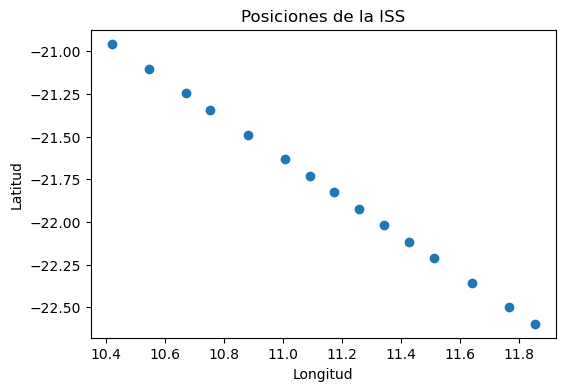

In [55]:
# Dibujar las posiciones
plt.figure(figsize=(6,4))
plt.scatter(df2['longitude'], df2['latitude'])
plt.title('Posiciones de la ISS')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

In [ ]:
# Puedo guardarlo en un csv y ya trabajar con él ;) 
df2.to_csv("satelite.csv",header=True, index=False)